In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob
import pandas as pd
import ArcTools as Atools
from datetime import datetime

### Vertical interpolation function

In [3]:
def interp_prof(x_old, y_old, x_new):

    from scipy.interpolate import Akima1DInterpolator
    inans_y = ~np.isnan(y_old)
    inans_x = ~np.isnan(x_old)
    inans = inans_y*inans_x
    if np.any(inans):
        if len(y_old[inans])>1:

            spl = Akima1DInterpolator(x_old[inans], y_old[inans])
            y_new = spl(x_new)
        else:
            y_new = []
    else:
        y_new = []
    
    return y_new

### Vertical grid ISAS

In [4]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data


In [5]:
test = xr.open_dataset('/data0/user/aprigent/NABOS/CTD2002/KD1002.nc')


In [7]:
DIR_OUT = '/data0/user/aprigent/NABOS/CTD/'
import os
for year in range(2002, 2025):
    print('----------------------')
    print(year)
    print('----------------------')
    nabos_path = f'/data0/user/aprigent/NABOS/CTD{year}/'
    list_nabos = glob.glob(nabos_path + '*.nc')

    for f in list_nabos:
        print(f)
        ds = xr.open_dataset(f,decode_times=False)
        
        basename = os.path.basename(f) 
        name_no_ext = os.path.splitext(basename)[0]

        # --- time extraction ---
        try:
            # extract scalar
            jd = float(ds.time.values.item())  # 0-dim array → float
            # convert Julian day to pandas Timestamp
            date = pd.to_datetime(jd, unit="D", origin="julian")
            date_ord = date.toordinal()  # integer day
            print(date_ord,datetime.fromordinal(date_ord))
        except Exception as e:
            print(f"1 Skipping file {f} due to time error: {e}")
            continue  # skip profile if time fails

        # --- Extract and process profile ---
        try:
            pres = ds.pressure.values
            lat = ds.latitude.values
            lon = ds.longitude.values
            psal = ds.salinity.values
            temp = ds.temperature.values

            # convert pressure to depth
            dep = -gsw.z_from_p(pres.T, lat).T
            
            sum_temp = np.array([np.nansum(temp)])
            sum_psal = np.array([np.nansum(psal)])

            sum_dep_t = np.array([np.nansum(dep[np.isfinite(temp)])])
            sum_dep_s = np.array([np.nansum(dep[np.isfinite(psal)])])

            nb_levels_t = np.array([np.isfinite(temp).sum()])
            nb_levels_s = np.array([np.isfinite(psal).sum()])

            # interpolate onto common depth grid
            psali = interp_prof(dep[:], psal, zi)
            tempi = interp_prof(dep[:], temp, zi)


            PSAL = np.array(psali)
            TEMP = np.array(tempi)
            LON = np.array([lon])
            LAT = np.array([lat])
            TIME = np.array([date_ord])
            
        except Exception as e:
            print(f"2 Skipping file {f} due to profile error: {e}")
            continue

        
        TEMP[TEMP<-2] = np.nan
        TEMP[TEMP>30] = np.nan
        PSAL[PSAL<0] = np.nan
        PSAL[PSAL>40] = np.nan
        print('TEMP mean = ',np.nanmean(TEMP))
        print('TEMP min = ',np.nanmin(TEMP))
        if np.nanmean(TEMP)>5:
            break
        
        PSAL_2d = PSAL[np.newaxis, :]
        TEMP_2d = TEMP[np.newaxis, :]

        #save TEMP/PSAL ZST file (ISAS grid)
        ds = xr.Dataset({'latitude': (['prof'], LAT),
                         'longitude': (['prof'], LON),
                         'time': (['prof'], TIME),
                         'salinity': (['prof','levels'], PSAL_2d),
                         'sum_salinity': (['prof'], sum_psal),
                         'sum_levels': (['prof'], sum_dep_s),
                         'nb_levels': (['prof'], nb_levels_s),
                         'depth': (['levels'], zi)},
                        coords={'prof': (['prof'], np.arange(0,len(TIME))),
                                'levels':(['levels'], zi)})

        # -----------------------
        # Global attributes
        # -----------------------
        ds.attrs['Comments'] = 'NABOS salinity profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'


        # optional extras (CF-style good practice)
        ds.attrs['title'] = 'NABOS salinity profiles on ISAS vertical grid'
        ds.attrs['source'] = 'NABOS'
        ds.attrs['history'] = 'Created with xarray'

        # -----------------------
        # Variable attributes
        # -----------------------
        ds['latitude'].attrs = {
            'long_name': 'Latitude',
            'units': 'degrees_north',
            'standard_name': 'latitude'
        }

        ds['longitude'].attrs = {
            'long_name': 'Longitude',
            'units': 'degrees_east',
            'standard_name': 'longitude'
        }

        ds['time'].attrs = {
            'long_name': 'Time',
            'units': 'days since 0001-01-01 (Python datetime system)'
        }

        ds['salinity'].attrs = {
            'long_name': 'Practical salinity',
            'units': '1e-3',   # or 'psu' depending on convention
            'standard_name': 'sea_water_practical_salinity (PSS-78)'
        }

        ds['depth'].attrs = {
            'long_name': 'Depth',
            'units': 'm',
            'positive': 'down',
            'standard_name': 'depth'
        }


        #
        ds.to_netcdf(DIR_OUT+name_no_ext+'_CTD_ISAS_PSAL.nc')  

        # save file TEMP
        ds = xr.Dataset({'latitude': (['prof'], LAT),\
                         'longitude': (['prof'], LON),\
                         'time': (['prof'], TIME),\
                         'temperature': (['prof','levels'], TEMP_2d),
                         'sum_temperature': (['prof'], sum_temp),
                         'sum_levels': (['prof'], sum_dep_t),
                         'nb_levels': (['prof'], nb_levels_t),
                         'depth': (['levels'], zi)},\
                        coords={'prof': (['prof'], np.arange(0,len(TIME))), 'levels':(['levels'], zi)})
        ds.attrs['Comments'] = 'NABOS temperature profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'


        # optional extras (CF-style good practice)
        ds.attrs['title'] = 'NABOS temperature profiles on ISAS vertical grid'
        ds.attrs['source'] = 'NABOS'
        ds.attrs['history'] = 'Created with xarray'

        # -----------------------
        # Variable attributes
        # -----------------------
        ds['latitude'].attrs = {
            'long_name': 'Latitude',
            'units': 'degrees_north',
            'standard_name': 'latitude'
        }

        ds['longitude'].attrs = {
            'long_name': 'Longitude',
            'units': 'degrees_east',
            'standard_name': 'longitude'
        }

        ds['time'].attrs = {
            'long_name': 'Time',
            'units': 'days since 0001-01-01 (Python datetime system)'
        }

        ds['temperature'].attrs = {
            'long_name': 'In-situ temperature',
            'units': 'degC',   # or 'psu' depending on convention
            'standard_name': 'sea_water_temperature T90'
        }

        ds['depth'].attrs = {
            'long_name': 'Depth',
            'units': 'm',
            'positive': 'down',
            'standard_name': 'depth'
        }


#
        ds.to_netcdf(DIR_OUT+name_no_ext+'_CTD_ISAS_TEMP.nc')

----------------------
2002
----------------------
/data0/user/aprigent/NABOS/CTD2002/KD502.nc
731094 2002-09-01 00:00:00
TEMP mean =  -0.34876021136985924
TEMP min =  -1.682744331325453
/data0/user/aprigent/NABOS/CTD2002/KD1102.nc
731096 2002-09-03 00:00:00
TEMP mean =  -0.18597751869932627
TEMP min =  -1.8117904493149395
/data0/user/aprigent/NABOS/CTD2002/KD2102.nc
731102 2002-09-09 00:00:00
TEMP mean =  -0.3006296408251404
TEMP min =  -1.7505314089080148
/data0/user/aprigent/NABOS/CTD2002/KD2002.nc
731102 2002-09-09 00:00:00
TEMP mean =  -0.3233989624496603
TEMP min =  -1.7436068401156488
/data0/user/aprigent/NABOS/CTD2002/KD2302.nc
731103 2002-09-10 00:00:00
TEMP mean =  -0.25879176989507713
TEMP min =  -1.7772252127675177
/data0/user/aprigent/NABOS/CTD2002/KD602.nc
731094 2002-09-01 00:00:00
TEMP mean =  -0.3113373742229741
TEMP min =  -1.7595168273421875
/data0/user/aprigent/NABOS/CTD2002/KD702.nc
731095 2002-09-02 00:00:00
TEMP mean =  -0.33221710486552714
TEMP min =  -1.7660440

2057

In [5]:
DIR_NABOS = '/data0/user/aprigent/NABOS/CTD/'
nabos_list_psal = glob.glob(DIR_NABOS + '*ISAS_PSAL.nc')
nabos_list_temp = glob.glob(DIR_NABOS + '*ISAS_TEMP.nc')


In [6]:
ds_nabos_psal = Atools.create_merged_dataset_psal(nabos_list_psal,'NABOS_ctd','psal')
ds_nabos_temp = Atools.create_merged_dataset_temp(nabos_list_temp,'NABOS_ctd','temp')


In [15]:
lon_all = np.array(ds_nabos_temp.longitude)
lat_all = np.array(ds_nabos_temp.latitude)
time_all = np.array(ds_nabos_temp.time)
psal_all = np.array(ds_nabos_temp.temperature)

In [16]:
%%time
duplicate_mask,duplicate_pairs = Atools.find_duplicates(lon_all,lat_all,time_all,psal_all)
array_duplicates = np.array(duplicate_pairs)

CPU times: user 25.7 ms, sys: 221 µs, total: 25.9 ms
Wall time: 41.8 ms


In [17]:
array_duplicates

array([], dtype=float64)

In [18]:

def plot_vertical_distribution(ds_psal,ds_temp,source):
    ftz=15
    finite_per_level_psal = np.sum(np.isfinite(ds_psal.salinity), axis=0)
    psal_mean = np.nanmean(ds_psal.salinity,axis=0)
    psal_std = np.nanstd(ds_psal.salinity,axis=0)
    
    finite_per_level_temp = np.sum(np.isfinite(ds_temp.temperature), axis=0)
    temp_mean = np.nanmean(ds_temp.temperature,axis=0)
    temp_std = np.nanstd(ds_temp.temperature,axis=0)
    
    
    f, ax = plt.subplots(2, 2, figsize=[10, 10], sharey=True)
    ax = ax.ravel()
    plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3
                    ,
                    wspace=0.2)
    # Plot profiles
    for i in range(ds_psal.profile.shape[0]):
        ax[0].scatter(ds_psal.salinity[i],
                      ds_psal.depth,
                      color='blue', s=1)
    ax[0].plot(psal_mean,ds_psal.depth,color='red',label=r'$\mu$')
    ax[0].plot(psal_mean+psal_std,ds_psal.depth,color='green',linestyle='--',label=r'$\mu$ +/- $\sigma$')
    ax[0].plot(psal_mean-psal_std,ds_psal.depth,color='green',linestyle='--')
    ax[0].plot(psal_mean+2*psal_std,ds_psal.depth,color='red',linestyle='--',label=r'$\mu$ +/- 2 $\sigma$')
    ax[0].plot(psal_mean-2*psal_std,ds_psal.depth,color='red',linestyle='--')
    ax[0].invert_yaxis()
    ax[0].set_xlabel("Salinity",fontsize=ftz)
    ax[0].set_ylabel("Depth (m)",fontsize=ftz)
    ax[0].set_ylim([3000,0])
    ax[0].legend(fontsize=ftz)
    ax[0].tick_params(labelsize=ftz)
    ax[0].set_title(source,fontsize=ftz)
    # Plot number of finite values per level
    ax[1].plot(finite_per_level_psal,ds_psal.depth,marker='.',color='black')
    ax[1].set_xlabel("Number of finite values",fontsize=ftz)
    ax[1].tick_params(labelsize=ftz)
    ax11 = ax[1].twiny()

    fraction = finite_per_level_psal / ds_psal.profile.shape[0]
    ax11.plot(fraction*100,ds_psal.depth,color='black')
    ax11.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax11.tick_params(labelsize=ftz)
    
    
    # Plot profiles
    for i in range(ds_temp.profile.shape[0]):
        ax[2].scatter(ds_temp.temperature[i],
                      ds_temp.depth,
                      color='blue', s=1)
    ax[2].plot(temp_mean,ds_temp.depth,color='red',label=r'$\mu$ ')
    ax[2].plot(temp_mean+temp_std,ds_temp.depth,color='green',linestyle='--',label=r'$\mu$ +/- $\sigma$')
    ax[2].plot(temp_mean-temp_std,ds_temp.depth,color='green',linestyle='--')
    ax[2].plot(temp_mean+2*temp_std,ds_temp.depth,color='red',linestyle='--',label=r'$\mu$ +/- 2$\sigma$')
    ax[2].plot(temp_mean-2*temp_std,ds_temp.depth,color='red',linestyle='--')
    ax[2].tick_params(labelsize=ftz)
    ax[2].invert_yaxis()
    ax[2].set_xlabel("Temperature ($^{\circ}$C)",fontsize=ftz)
    ax[2].set_ylabel("Depth (m)",fontsize=ftz)
    ax[2].set_ylim([3000,0])
    ax[2].legend(fontsize=ftz)
    ax[2].set_title(source,fontsize=ftz)
    # Plot number of finite values per level
    ax[3].plot(finite_per_level_temp,ds_temp.depth,marker='.',color='black')
    ax[3].set_xlabel("Number of finite values",fontsize=ftz)
    ax[3].tick_params(labelsize=ftz)
    ax33 = ax[3].twiny()

    fraction = finite_per_level_temp / ds_temp.profile.shape[0]
    ax33.plot(fraction*100,ds_temp.depth,color='black')
    ax33.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax33.tick_params(labelsize=ftz)
    return f
    


/tmp/ipykernel_73942/1003643437.py:4: RuntimeWarning: Mean of empty slice
  psal_mean = np.nanmean(ds_psal.salinity,axis=0)
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_73942/1003643437.py:8: RuntimeWarning: Mean of empty slice
  temp_mean = np.nanmean(ds_temp.temperature,axis=0)
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


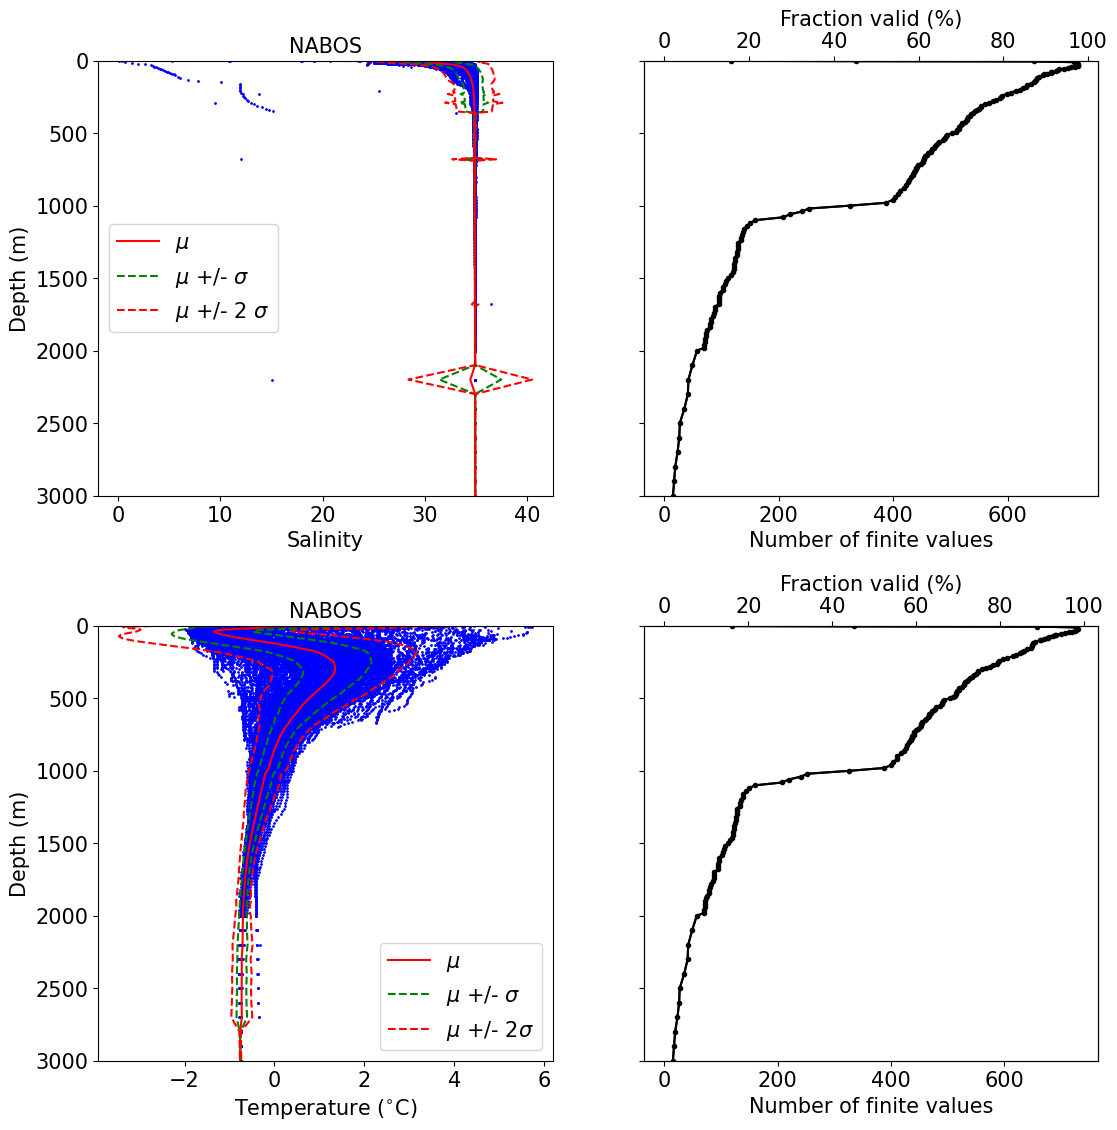

In [20]:
plot_vertical_distribution(ds_nabos_psal,ds_nabos_temp,source='NABOS')
plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_data_NABOS_vert_distribution.png',bbox_inches='tight',dpi=300)